In [1]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pendulum
import optuna

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False


# Load Files

In [2]:
df_20XX = pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2009.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])

for x in range(2010,2021):
  df_20XX = pd.concat(objs = (df_20XX, pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{x}.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])))

load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'
regiao = 'SUDESTE'

In [3]:
df_20XX.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,NORTE,2009-01-01,3330.302917
1,NE,NORDESTE,2009-01-01,6138.174583
2,S,SUL,2009-01-01,6085.486507
3,SE,SUDESTE,2009-01-01,22893.838750
4,N,NORTE,2009-01-02,3480.832083


# Treat data

In [4]:
def get_missing_days(df):
  # range of every day from 2001 to 2021
  time_delta = pd.date_range(start = df.din_instante.iloc[0], end= df.din_instante.iloc[-1],freq='D')
  # turn into df
  df_time = pd.DataFrame(data={'data':time_delta})
  # left join range of data with datas from dataset, missing days will become NaN
  df_missing = df_time.join(df.set_index('din_instante'), on='data', how='left')
  # missing days indexes
  df_missing.val_cargaenergiamwmed[df_missing.val_cargaenergiamwmed.isnull()]
  # series of missing days with indexes
  missing_days = df_missing.loc[df_missing.val_cargaenergiamwmed[df_missing.val_cargaenergiamwmed.isnull()].index].data
  return missing_days

def id_and_impute(df):

  # series of missing days with indexes
  missing_days = get_missing_days(df) 
  if len(df[df.din_instante == '2014-01-01']) == 1:
    # drop days from incomplete week in 2016
    df = df.drop(axis=0, index = df.din_instante[(df[time_col]>='2016-04-01') & (df[time_col]<='2016-04-05')].index)
    df = df.drop(axis=0, index = missing_days.index[1]-1)
    # missing day to be inputed - feb 1st, 2014
    imput_day = df['din_instante'].iloc[missing_days.index[0]]
    # line to be inserted in dataset with load value of day before
    df_day = pd.DataFrame({'din_instante': imput_day-pd.Timedelta(1, unit='D'),	
                          'val_cargaenergiamwmed': df[load_col].iloc[missing_days.index[0] - 1]},
                          index=[missing_days.index[0] -1 ])
    # insert missing day
    df = pd.concat(objs= [df[:missing_days.index[0]], 
                                df_day, 
                                df[missing_days.index[0]:]])
  
  #reset index
  return  df, missing_days

def go_to_friday(df): 
  """ get next friday = start the operative week"""
  
  # first day in dataset
  date_time = df['din_instante'].iloc[0]
  # check if the dataset starts on a friday 
  if date_time.day_name() != 'Friday':
    # today
    dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
    # next friday - begins the operative week
    next_friday = dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')
    # df starts with the begin of operative week
    df = df[df['din_instante'] >= next_friday].reset_index(drop=True).copy()
  
  return df

def treat_data(df,regiao='SUDESTE',operative_week_start=2):
  
  # round the values of load
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # drop na rows that doesn't have load values
  df.dropna(axis=0, how='any',inplace=True)
  # filter data by subsystem region
  try:
    df = df[df.nom_subsistema==regiao].reset_index().drop('index',
                                                             axis=1).copy()
  except:
    pass
  # drops columns about region
  df.drop(labels=['nom_subsistema','id_subsistema'], 
          inplace=True, axis=1,errors='ignore')


  # check if the dataset starts on a friday and go to friday if it does not 
  df = go_to_friday(df)
  # insert missing data from 1st feb'2014
  df, _ = id_and_impute(df) 

  # create column with week number 
  df.reset_index(inplace=True,drop=True)
  df['semana'] = (df.index)//7 

  df['Mes'] = df['din_instante'].dt.month
  df['dia semana'] = df['din_instante'].dt.day_name()
  df['dia mes'] = df['din_instante'].dt.day
  df['ano'] = df['din_instante'].dt.year
  
  return df

df = treat_data(df_20XX, regiao='SUDESTE')
df.head(3)

,din_instante,val_cargaenergiamwmed,semana,Mes,dia semana,dia mes,ano
0,2009-01-02,26104.57,0,1,Friday,2,2009
1,2009-01-03,25754.14,0,1,Saturday,3,2009
2,2009-01-04,23795.99,0,1,Sunday,4,2009


# Initialize constants

In [5]:
batch_size = 32
# target days to sum into weeks
target_period = 7 
# number of weeks in the window
n_weeks_ws = 20
# window size in days for each row
window_size = 7*n_weeks_ws
filepath = 'NB8.h5'
shuffle_buffer = 20
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# index of end of training dataset, start of validation dataset
split_val = int(len(df)*0.7)
# index of end of validation dataset, start of test dataset
split_test = int(len(df)*0.9)
# date when starts the validation and test sets 
date_val = df.iloc[split_val][time_col]
date_test = df.iloc[split_test][time_col]
# window_size date interval
delta_window = pd.to_timedelta(window_size,unit='d')
# split validation data date + window_size
d2 = date_val + delta_window
# split test data date + window_size
d3 = date_test + delta_window 


print('window_size = ',window_size)
print('validation set start date = ', date_val)
print('test set start date = ', date_test)

window_size =  140
validation set start date =  2017-05-31 00:00:00
test set start date =  2019-10-22 00:00:00


# target

In [6]:
def create_target_df(df):
  if df['din_instante'].iloc[0].day_name() != 'Friday':
    # get next friday - begins the operative week
    next_fri = get_friday(df['din_instante'].iloc[0])
    # df starts with the begin of operative week
    df = df[df['din_instante'] >= next_fri].copy()
  # average daily load by operative week
  df_target = pd.DataFrame(data=df.groupby(by=['semana'])[load_col].mean())
  # start day of each operative week
  df_target['Data'] = df.groupby(by=['semana'])[time_col].min()
  return df_target

df_target = create_target_df(df)

In [7]:
df_target

,val_cargaenergiamwmed,Data
semana,,
0,27536.564286,2009-01-02
1,31029.192857,2009-01-09
2,30444.171429,2009-01-16
3,29957.377143,2009-01-23
4,31392.350000,2009-01-30
...,...,...
619,41549.148571,2020-11-27
620,39519.355714,2020-12-04
621,40279.662857,2020-12-11


# split data

In [8]:
regiao = 'SUDESTE'
def split_time(split_val = split_val, 
               split_test = split_test,
               df=df_20XX,
               regiao=regiao):
  df = df.copy()
  df = treat_data(df, regiao = regiao)
  # split datasets
  train_df = df[0:split_val].copy()
  val_df = df[split_val:split_test].copy()
  test_df = df[split_test:].copy()
  
  return (treat_data(train_df,regiao = regiao), 
         treat_data(val_df,regiao = regiao), 
         treat_data(test_df,regiao = regiao))


train_df, val_df, test_df = split_time(split_val = split_val, 
                                       split_test = split_test,
                                       df=df_20XX,
                                       regiao=regiao)

def time_delta(d):
  return pd.to_timedelta(d,unit='d')

# TensorFlow Dataset

In [9]:
def windowed_dataset(df, batch_size = batch_size, 
                     window_size = window_size, shuffle_buffer = shuffle_buffer, 
                     target_period = target_period,
                     shuffle=True):
  df = df.copy()
  
  # check if the dataset starts on a friday and go to friday if it does not 
  df = go_to_friday(df)
  # groupby object by week and then by day
  df_grouped = df[window_size:].groupby(by=['semana'])['din_instante']
  # get first day of each week
  data_week = df_grouped.min()
  # if last week is incomplete, drop it
  if df_grouped.count().iloc[-1]!=7:
    data_week = data_week[:-1]


  series = df[load_col  ]
  # generate tf.dataset
  dataset = tf.data.Dataset.from_tensor_slices(series)
  # create windows 
  dataset = dataset.window(window_size + target_period, shift=7, drop_remainder=True)
  # make sure every window is the same size / clip NaN at the end
  dataset = dataset.flat_map(lambda window: window.batch(window_size + target_period))
  if shuffle:
    # randomly shuffles the windows instances in the dataset 
    dataset = dataset.shuffle(shuffle_buffer,seed=SEED)
  # separates features and target and average the target days
  dataset = dataset.map(lambda window:(window[:-target_period],
                                       tf.math.reduce_sum(window[-target_period:])/target_period))
  # batch and prefetch
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset, data_week

# dataset to training
train_dataset, train_data_week = windowed_dataset(df = train_df)
# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = windowed_dataset(df = train_df, shuffle=False)
val_dataset, val_data_week = windowed_dataset(df = val_df, shuffle=False)
test_dataset, test_data_week = windowed_dataset(df = test_df, shuffle=False)

In [10]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
print(c*batch_size)

416


# Baseline

In [11]:
# baseline = load from last week
df_target['baseline'] = df_target[load_col].shift(1)
df_target.head()

,val_cargaenergiamwmed,Data,baseline
semana,,,
0,27536.564286,2009-01-02,NaN
1,31029.192857,2009-01-09,27536.564286
2,30444.171429,2009-01-16,31029.192857
3,29957.377143,2009-01-23,30444.171429
4,31392.350000,2009-01-30,29957.377143


In [12]:
# indexes for .loc for each set of data 
train_ix_base = ((df_target['Data'] < date_val) & (df_target['Data'] >= '2009-05-22'))
val_ix_base = ((df_target['Data'] > d2) & (df_target['Data']<date_test))
test_ix_base = df_target['Data']> d3


# metrics for baseline model
metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data = 

          {'MAE' : [tf.keras.metrics.mean_absolute_error(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MAPE' : [tf.keras.metrics.mape(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MSE' : [tf.keras.metrics.mse(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],

          'MSLE' : [tf.keras.metrics.msle(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]]          
          })

metrics_baseline

,MAE,MAPE,MSE,MSLE
train,1084.456116,3.069598,2.118258e+06,0.001670
val,1162.833352,3.132926,2.496372e+06,0.001770
test,1493.004216,4.113104,4.137918e+06,0.002967


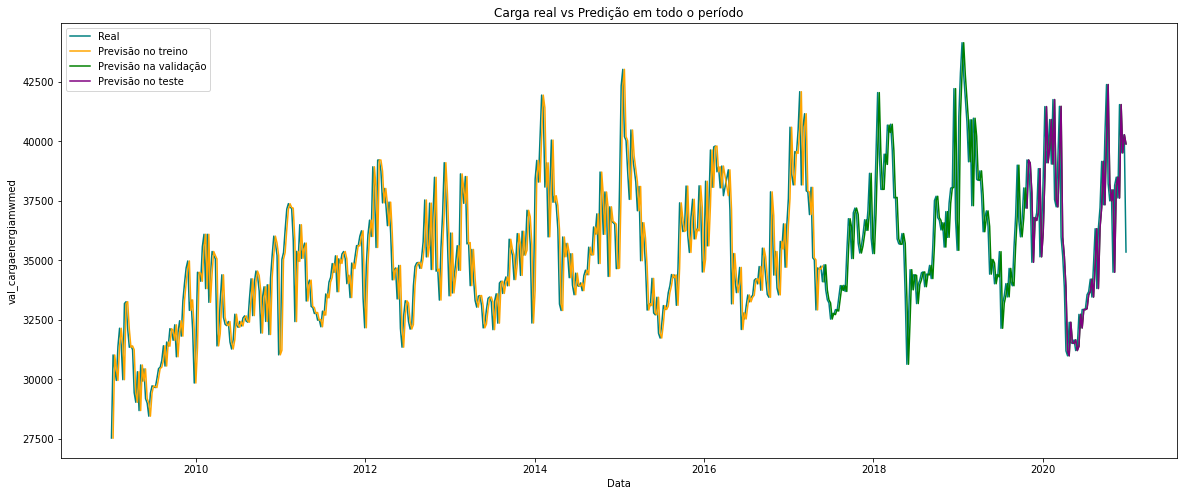

In [13]:
fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], 
             ax=ax, color = 'teal')

# plot predicted training data
sns.lineplot(x = df_target.loc[df_target['Data']<date_val][1:].Data, 
             y = df_target.loc[df_target['Data']<date_val][1:].baseline,
             ax=ax, color='orange')

# plot predicted validation data
sns.lineplot(x = df_target[df_target['Data']>date_val].Data, 
             y = df_target[df_target['Data']>date_val].baseline,
             ax=ax, color='green')

# plot predicted test data
sns.lineplot(x = df_target[df_target['Data']>date_test].Data, 
             y = df_target[df_target['Data']>date_test].baseline,
             ax=ax, color='purple')

#plt.plot(df.din_instante[split_val:],np.array(forecast)[split_val-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])

# mudar linha de pred pra pontilhado

# model optmization

In [17]:
def create_model(trial):
    # We optimize the numbers of layers, their units and weight decay parameter.
    n_layers = trial.suggest_int("n_layers", 1, 3)
    #weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-3, log=True)
    
    model = tf.keras.models.Sequential([
                        # fix dimensions
                        tf.keras.layers.Lambda(lambda x: 
                                               tf.expand_dims(x, axis = -1), 
                                               input_shape=[None]),
                        # normalize data
                        tf.keras.layers.BatchNormalization() 
                        ])
    # loop to generate hidden layers
    for i in range(n_layers):
        # number of memory cells
        num_hidden = trial.suggest_int("n_units_l{}".format(i), 4, 64, log=True)
        if i == n_layers:
              return_sequences = False
        else:
              return_sequences = True
        model.add(
            tf.keras.layers.LSTM(
                num_hidden,
                activation="tanh", # pesquisar se há alguma alternativa para o aoutuput da LSTM seja mais próximo do output final
                #kernel_regularizer=tf.keras.regularizers.l2(weight_decay),
                return_sequences=return_sequences
                                )
                )
    model.add(
        tf.keras.layers.Dense(1) #,kernel_regularizer=tf.keras.regularizers.l2(weight_decay)) # tentar outras ativações
        )
    model.add(
        tf.keras.layers.Lambda(lambda x: x * 10000.0) # procurar sobre reverter batch normalization
        )
    return model

def create_optimizer(trial):
    # We optimize the choice of optimizers as well as their parameters.
    kwargs = {}
    optimizer_options = ["Adam"] #, "RMSprop", "Adagrad"]
    optimizer_selected = trial.suggest_categorical("optimizer", optimizer_options)
    if optimizer_selected == "RMSprop":
        kwargs["learning_rate"] = trial.suggest_float(
            "rmsprop_learning_rate", 1e-5, 1e-1, log=True
        )
        kwargs["decay"] = trial.suggest_float("rmsprop_decay", 0.85, 0.99)
        kwargs["momentum"] = trial.suggest_float("rmsprop_momentum", 1e-5, 1e-1, log=True)
    elif optimizer_selected == "Adam":
        kwargs["learning_rate"] = trial.suggest_float("adam_learning_rate", 1e-3, 1e-2, log=True)
    elif optimizer_selected == "Adagrad":
        kwargs["learning_rate"] = trial.suggest_float(
            "adagrad_learning_rate", 1e-5, 1, log=True
        )
        kwargs["epsilon"] = trial.suggest_float("adagrad_epsilon", 1e-8, 1e-6, log=True)

    optimizer = getattr(tf.optimizers, optimizer_selected)(**kwargs)
    return optimizer

def comp_fit_tuning(model, data, val_data, optimizer, epochs, patience):
    # early stopping callback
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                      patience=patience,
                                                      mode='min')
    # compile
    model.compile(loss=tf.losses.MeanSquaredError(),
                  optimizer=optimizer,
                  metrics=[tf.metrics.MeanAbsoluteError(),
                            tf.metrics.MeanAbsolutePercentageError(),
                            tf.keras.metrics.RootMeanSquaredError()])
    # fit data
    history = model.fit(data, epochs=epochs, verbose=0,
                        validation_data= val_data,
                        callbacks=[early_stopping]) 
    return history

def objective(trial):

    # Build model and optimizer.
    model = create_model(trial)
    optimizer = create_optimizer(trial)

    # Training and validating cycle.
    history = comp_fit_tuning(model=model, 
                              epochs = 100, 
                              data=train_dataset, 
                              val_data = val_dataset,
                              patience = 60, 
                              optimizer=optimizer)


    # Return loss
    return model.evaluate(val_dataset)[0]

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=300)

print("Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2022-03-15 02:40:33,334] A new study created in memory with name: no-name-f9e6acd8-901a-4539-afab-7319e3ce6601


4/4 [==============================] - 0s 22ms/step - loss: 8272515.5000 - mean_absolute_error: 2173.5269 - mean_absolute_percentage_error: 5.7067 - root_mean_squared_error: 2926.9001


[I 2022-03-15 02:42:10,185] Trial 0 finished with value: 8272515.5 and parameters: {'n_layers': 2, 'n_units_l0': 6, 'n_units_l1': 21, 'optimizer': 'Adam', 'adam_learning_rate': 0.006741284375233166}. Best is trial 0 with value: 8272515.5.


4/4 [==============================] - 0s 39ms/step - loss: 8215940.5000 - mean_absolute_error: 2169.2981 - mean_absolute_percentage_error: 5.6969 - root_mean_squared_error: 2918.4888


[I 2022-03-15 02:44:05,832] Trial 1 finished with value: 8215940.5 and parameters: {'n_layers': 2, 'n_units_l0': 10, 'n_units_l1': 32, 'optimizer': 'Adam', 'adam_learning_rate': 0.004227447322899146}. Best is trial 1 with value: 8215940.5.


...

4/4 [==============================] - 0s 30ms/step - loss: 7501611.5000 - mean_absolute_error: 2087.9343 - mean_absolute_percentage_error: 5.5198 - root_mean_squared_error: 2792.2542


[I 2022-03-16 07:45:47,148] Trial 298 finished with value: 7501611.5 and parameters: {'n_layers': 2, 'n_units_l0': 23, 'n_units_l1': 58, 'optimizer': 'Adam', 'adam_learning_rate': 0.009581142534269569}. Best is trial 165 with value: 6886491.5.


4/4 [==============================] - 0s 26ms/step - loss: 7648760.5000 - mean_absolute_error: 2120.6836 - mean_absolute_percentage_error: 5.6137 - root_mean_squared_error: 2816.3616


[I 2022-03-16 07:48:06,129] Trial 299 finished with value: 7648760.5 and parameters: {'n_layers': 2, 'n_units_l0': 27, 'n_units_l1': 61, 'optimizer': 'Adam', 'adam_learning_rate': 0.009181382583783886}. Best is trial 165 with value: 6886491.5.


Number of finished trials:  300
Best trial:
  Value:  6886491.5
  Params: 
    n_layers: 2
    n_units_l0: 23
    n_units_l1: 59
    optimizer: Adam
    adam_learning_rate: 0.008260539609105095


# Train model


In [ ]:
def compile_and_fit(model, data, val_data, epochs,optimizer,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=optimizer,
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanAbsolutePercentageError(),
                         tf.keras.metrics.RootMeanSquaredError()])  
  # fit data
  history = model.fit(data, epochs=epochs, verbose=1,
                      validation_data= val_data,
                      callbacks=[early_stopping]) #, checkpoint]) 
  return history

In [ ]:
weight_decay = 5.29435315233284e-06

optimizer = tf.optimizers.Adam(learning_rate=0.007) #Adagrad(learning_rate= 0.9580, epsilon = 2.645-08)

l0 = tf.keras.layers.LSTM(5, return_sequences=True, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
                          activation ='tanh')
l1 = tf.keras.layers.LSTM(5, return_sequences=False,                                    # sequence to sequence learning
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
                          activation ='tanh')
l2 = tf.keras.layers.LSTM(28, return_sequences=True, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
                          activation ='tanh')
l3 = tf.keras.layers.LSTM(15, return_sequences=False, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
                          activation ='tanh')
# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    l0,
    l1,
    #l2,
    #l3,
    tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 200, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = optimizer,
                          patience = 90,
                          filepath = filepath)

#print(os.listdir())

#print("Layer weights {}".format(l0.get_weights()))

Epoch 1/200
13/13 [==============================] - 9s 191ms/step - loss: 1035047936.0000 - mean_absolute_error: 32090.1699 - mean_absolute_percentage_error: 92.0506 - val_loss: 625535360.0000 - val_mean_absolute_error: 24876.8965 - val_mean_absolute_percentage_error: 67.5807
Epoch 2/200
13/13 [==============================] - 1s 107ms/step - loss: 389423392.0000 - mean_absolute_error: 19445.7363 - mean_absolute_percentage_error: 56.0083 - val_loss: 215377552.0000 - val_mean_absolute_error: 14433.2539 - val_mean_absolute_percentage_error: 38.9920
Epoch 3/200
13/13 [==============================] - 1s 111ms/step - loss: 76438984.0000 - mean_absolute_error: 8408.4980 - mean_absolute_percentage_error: 23.9523 - val_loss: 45250348.0000 - val_mean_absolute_error: 6174.3462 - val_mean_absolute_percentage_error: 16.3926
Epoch 4/200
13/13 [==============================] - 2s 118ms/step - loss: 6518815.0000 - mean_absolute_error: 1991.5851 - mean_absolute_percentage_error: 5.4911 - val_loss

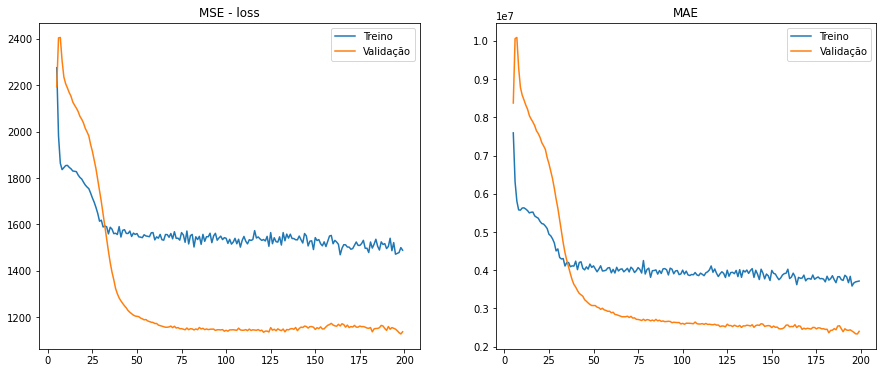

In [ ]:
# evaluate training metrics

# starting epoch to plot
skip = 5

fig,ax = plt.subplots(figsize=(15,6), nrows=1, ncols=2)
metrics_list = ['loss',
                'val_loss',
                'mean_absolute_error', 
                'val_mean_absolute_error']

for i, metric in enumerate(metrics_list):
  if i>=2:
    ax1 =  ax.ravel()[0]
  else:
    ax1 =  ax.ravel()[1]
  sns.lineplot(x = range(skip,len(history.history[metric])),
              y = history.history[metric][skip:],
              ax = ax1)


ax.ravel()[0].set_title("MSE - loss")
ax.ravel()[0].legend(labels=['Treino', 'Validação'])
ax.ravel()[1].set_title("MAE")
ax.ravel()[1].legend(labels=['Treino', 'Validação'])

plt.show()

# Prediction

## loop dataset - continuos prediction

In [ ]:
# forecast
forecast = []
forecast_date = []
for time in range(0,len(df) - window_size,7):
  forecast.append(model.predict(np.array(df[load_col][time:time + window_size])[np.newaxis]))
  forecast_date.append(df[time_col].iloc[time + window_size])

# unnest nested data
forecast = np.array(forecast)[:,0,0]
# dataframe with date and load
pred_result = pd.DataFrame(data = {'Data' : forecast_date, 
                                   'Carga_prev' : forecast})
# join measured target values
metrics_pred = pred_result.set_index('Data').join(df_target.set_index('Data'), 
                                                  how='left', 
                                                  on='Data').reset_index()
# evaluate performance
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset)

2/2 [==============================] - 0s 50ms/step - loss: 4121106.0000 - mean_absolute_error: 1695.5154 - mean_squared_error: 4121106.0000 - mean_absolute_percentage_error: 4.7742


In [ ]:
def generate_metrics(pred_result, date_val=date_val,
                  d2=d2,d3=d3,df_target=df_target): 

  # indexes of each set of data
  train_ix = pred_result['Data'] < date_val
  val_ix = (pred_result['Data'] > d2) & (pred_result['Data']<date_test)
  test_ix = pred_result['Data'] > d3

  index_split = [train_ix, val_ix, test_ix] 
    # join measured target values
  metrics_pred = pred_result.set_index('Data').join(df_target.set_index('Data'), 
                                                    how='left', 
                                                    on='Data').reset_index()

  metrics_df = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data =
                            {'MAE' : [tf.keras.metrics.mean_absolute_error(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MAPE' : [tf.keras.metrics.mape(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MSE' : [tf.keras.metrics.mse(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MSLE' : [tf.keras.metrics.msle(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            })

  return metrics_df

metrics_df = generate_metrics(pred_result)
metrics_df

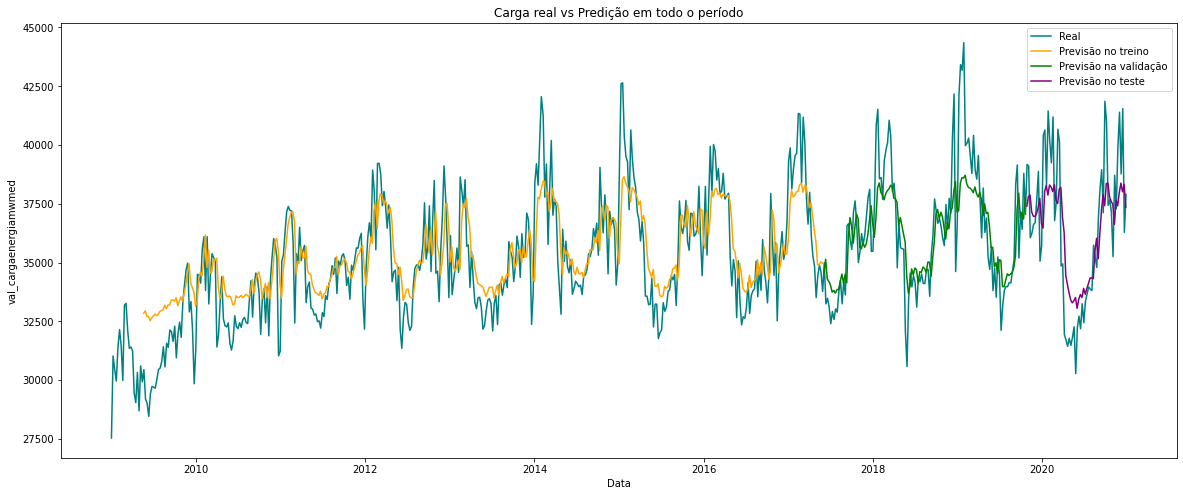

In [ ]:
# indexes of each set of data
train_ix = pred_result['Data'] < date_val
val_ix = (pred_result['Data']>date_val) & (pred_result['Data']<date_test)
test_ix = pred_result['Data']>date_test

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], ax=ax, color = 'teal')

# plot predicted training data
for ix, color in zip([train_ix, val_ix, test_ix],['orange','green','purple']):
  sns.lineplot(x = pred_result.loc[ix].Data,
               y = pred_result.loc[ix].Carga_prev, 
               ax=ax, color=color)
scores = f"MAE on val : {metrics_df.MAE.iloc[0]}"

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])

## .predict

2/2 [==============================] - 0s 59ms/step - loss: 2808153.2500 - mean_absolute_error: 1339.9171 - mean_absolute_percentage_error: 3.7205


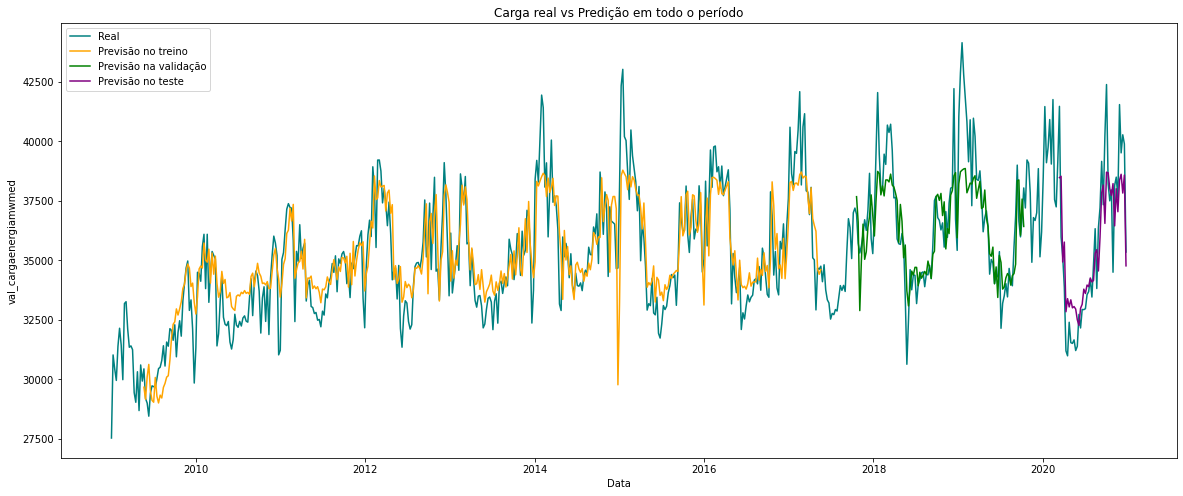

In [ ]:
train_pred = model.predict(train_pred_dataset)[:, 0]
val_pred = model.predict(val_dataset)[:, 0]
test_pred = model.predict(test_dataset)[:, 0]

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], ax=ax, color = 'teal')

# plot predicted data
for date,pred,color in zip([train_pred_data_week,val_data_week,test_data_week], 
                           [train_pred, val_pred, test_pred],
                           ['orange', 'green', 'purple']): 
  sns.lineplot(x = date,
               y = pred, 
               ax=ax, 
               color=color)
#scores = f"MAE on val : {metrics_df.MAE.iloc[0]}"

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 
            'Previsão no treino', 
            'Previsão na validação', 
            'Previsão no teste'])

# evaluate performance
train_performance = {}
train_performance['LSTM'] = model.evaluate(train_dataset)
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset)

# Save model weights

In [ ]:
# Save the entire model to a HDF5 file.
# The '.h5' extension indicates that the model should be saved to HDF5.
model.save('LSTM.h5') 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')